# Exploratory Data Analysis

Explore and understand the input data for the model

In [1]:
import polars as pl
import seaborn as sns

from pyprojroot import here

In [2]:
users = pl.read_csv(here("data/all_usernames_scored.csv"))

In [3]:
users

username,score
str,f64
"""nice_pages""",0.0
"""OUYKEH""",0.0
"""PermanentThrowaway2""",0.0
"""mrlawrencelady""",0.0
"""yiyic020""",0.0
…,…
"""OutrageousAnimals""",0.0
"""crudehumourisdivine""",0.0
"""Bong_rippa420""",0.0


In [4]:
print(f"Liberal users: {len(users.filter(pl.col("score") < -0.4))}")
print(f"Conservate users: {len(users.filter(pl.col("score") > 0.4))}")
print(f"Proportion of neutral users: {100*len(users.filter(pl.col("score") == 0))/ len(users)}")

Liberal users: 2138
Conservate users: 2248
Proportion of neutral users: 99.88370469043969


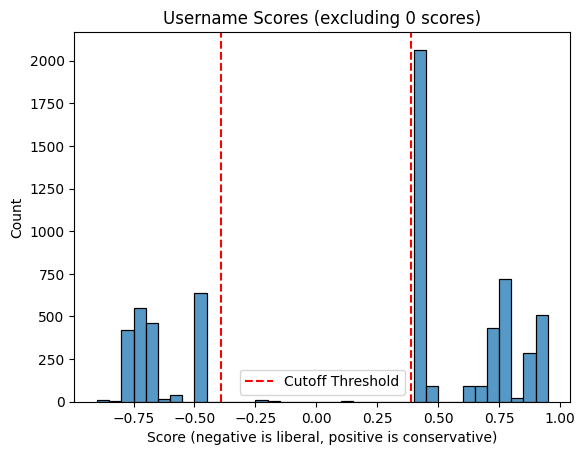

In [5]:
ax = sns.histplot(
    users.filter(pl.col("score") != 0), x="score",
    binwidth=0.05)
ax.axvline(x=-0.39, linestyle="--", color="red", label="Cutoff Threshold")
ax.axvline(x=0.39, linestyle="--", color="red")
ax.set_title("Username Scores (excluding 0 scores)")
ax.set_xlabel("Score (negative is liberal, positive is conservative)")
ax.legend()

In [6]:
users.sort(by=pl.col("score"), descending=False).head(10)

username,score
str,f64
"""FeelTheBernCallTheDr""",-0.9
"""Canyoufeelthebern""",-0.9
"""FeelTheBernanke""",-0.9
"""IFeelTheBern""",-0.9
"""feeltheberncream""",-0.9
"""feelthebern2016""",-0.9
"""FEEL_THE_BERN89""",-0.9
"""FeelTheBernVictim""",-0.9
"""IFeelTheBernWhenIPee""",-0.9


In [7]:
users.sort(by=pl.col("score"), descending=True).head(10)

username,score
str,f64
"""magazinelady""",0.95
"""MAGA_NW""",0.95
"""Magaa""",0.95
"""Maga-Munchkin""",0.95
"""MAGA_ME""",0.95
"""magadson""",0.95
"""Magalicious001""",0.95
"""magarraj""",0.95
"""MAGA_AllOverYourAss""",0.95


In [8]:
full = pl.read_csv(here("data/all_direct_replies.csv"), has_header=True, separator=chr(0), quote_char=None)
header = full.columns[0]
header_split = header.split(",")
full = full.select(
    pl.col(header)
    .str.splitn(",", len(header_split))
    .struct.rename_fields(header_split)
    .alias("fields")
).unnest("fields")
full = full.with_columns(
    pl.col("username_score").cast(pl.Float64)
)

In [9]:
print(f"Liberal label replies: {len(full.filter(pl.col("username_score") < -0.39))}")
print(f"Conservative label replies: {len(full.filter(pl.col("username_score") > 0.39))}")

Liberal label replies: 12971
Conservative label replies: 17571


In [10]:
experiment = pl.read_parquet(here("data/experiment.parquet"))

In [11]:
len(experiment)

230